In [11]:
#!pip install scikit-learn pandas joblib

In [12]:
import pandas as pd
import numpy as np
import joblib

#from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from time import perf_counter

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [13]:
#from google.colab import drive
#drive.mount('/content/drive', force_remount=True)

In [14]:
import os

ruta = "../model_files/"

print(os.listdir(ruta))

['spanish_dataset.csv', 'language_detector_v1.pkl', 'spam_ham_model.pkl', 'english_dataset.csv', 'es.txt', 'tfidf_spam.pkl', 'pt.txt', 'en.txt', 'fr.txt']


In [15]:
languages = {
    "spanish": "../model_files/es.txt",
    "english": "../model_files/en.txt",
    "portuguese": "../model_files/pt.txt",
    "french": "../model_files/fr.txt"
}

In [16]:
MAX_SAMPLES_PER_LANGUAGE = 300000

texts = []
labels = []

for language, path in languages.items():

    print(f"Cargando muestra de {language}...")

    count = 0

    with open(path, "r", encoding="utf-8", errors="ignore") as file:

        for line in file:

            line = line.strip()

            if len(line) > 30:

                texts.append(line)
                labels.append(language)
                count += 1

            if count >= MAX_SAMPLES_PER_LANGUAGE:
                break

print(f"\nTotal de textos cargados: {len(texts)}")

Cargando muestra de spanish...
Cargando muestra de english...
Cargando muestra de portuguese...
Cargando muestra de french...

Total de textos cargados: 1200000


In [17]:
df = pd.DataFrame({
    "text": texts,
    "language": labels
})

print(df["language"].value_counts())

language
spanish       300000
english       300000
portuguese    300000
french        300000
Name: count, dtype: int64


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text"],
    df["language"],
    test_size=0.2,
    random_state=42,
    stratify=df["language"]
)

In [19]:
model = Pipeline([

    (
        "tfidf",

        TfidfVectorizer(
            analyzer="char",
            ngram_range=(3,6),
            min_df=5
        )
    ),

    (
        "classifier",

        LogisticRegression(
            max_iter=1000,
            verbose=1
        )
    )

])

In [20]:
print("Iniciando entrenamiento...")
start_time = perf_counter()
model.fit(X_train, y_train)
elapsed_time = perf_counter() - start_time
print(f"Entrenamiento completado en {elapsed_time:.2f} segundos.")

Iniciando entrenamiento...
Entrenamiento completado en 1408.37 segundos.


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed: 18.2min finished


In [21]:
predictions = model.predict(X_test)

In [22]:
accuracy = accuracy_score(y_test, predictions)

print("Accuracy del modelo:", accuracy)

Accuracy del modelo: 0.9935291666666667


In [23]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

     english       1.00      1.00      1.00     60000
      french       0.99      1.00      0.99     60000
  portuguese       1.00      1.00      1.00     60000
     spanish       1.00      0.98      0.99     60000

    accuracy                           0.99    240000
   macro avg       0.99      0.99      0.99    240000
weighted avg       0.99      0.99      0.99    240000



In [24]:
samples = [

    # =========================
    # ESPAÑOL (5)
    # =========================

    "Estimado cliente, su factura electrónica ya está disponible para descarga.",

    "Hemos detectado un inicio de sesión desde un dispositivo nuevo en su cuenta.",

    "Su pedido ha sido enviado y llegará en los próximos días.",

    "Por favor confirme sus datos personales para continuar utilizando el servicio.",

    "Le informamos que su cita ha sido programada exitosamente para mañana.",


    # =========================
    # INGLÉS (5)
    # =========================

    "Your payment has been successfully processed and confirmed.",

    "Please verify your account information to avoid service interruption.",

    "We detected unusual activity on your account from a new location.",

    "Your package is currently in transit and will arrive soon.",

    "Thank you for subscribing to our monthly newsletter.",


    # =========================
    # PORTUGUÉS (5)
    # =========================

    "Seu pagamento foi processado com sucesso e confirmado.",

    "Detectamos uma tentativa de acesso em sua conta a partir de outro dispositivo.",

    "Sua encomenda foi enviada e chegará nos próximos dias.",

    "Por favor atualize suas informações para continuar utilizando o serviço.",

    "Obrigado por utilizar nossa plataforma de atendimento.",


    # =========================
    # FRANCÉS (5)
    # =========================

    "Votre paiement a été traité avec succès.",

    "Nous avons détecté une connexion depuis un nouvel appareil.",

    "Votre commande a été expédiée et arrivera prochainement.",

    "Veuillez confirmer vos informations personnelles pour continuer.",

    "Merci d'utiliser notre service en ligne."
]

sample_predictions = model.predict(samples)

for text, pred in zip(samples, sample_predictions):
    print(f"{pred} --> {text}")

spanish --> Estimado cliente, su factura electrónica ya está disponible para descarga.
spanish --> Hemos detectado un inicio de sesión desde un dispositivo nuevo en su cuenta.
spanish --> Su pedido ha sido enviado y llegará en los próximos días.
spanish --> Por favor confirme sus datos personales para continuar utilizando el servicio.
spanish --> Le informamos que su cita ha sido programada exitosamente para mañana.
english --> Your payment has been successfully processed and confirmed.
english --> Please verify your account information to avoid service interruption.
english --> We detected unusual activity on your account from a new location.
english --> Your package is currently in transit and will arrive soon.
english --> Thank you for subscribing to our monthly newsletter.
portuguese --> Seu pagamento foi processado com sucesso e confirmado.
portuguese --> Detectamos uma tentativa de acesso em sua conta a partir de outro dispositivo.
portuguese --> Sua encomenda foi enviada e chega

In [25]:
probabilities = model.predict_proba(samples)

print(probabilities)

[[2.19951802e-03 8.42450661e-03 3.46484897e-02 9.54727486e-01]
 [2.05461033e-05 3.79053551e-05 5.23095914e-05 9.99889239e-01]
 [3.29762552e-04 4.84205728e-04 1.13459926e-03 9.98051432e-01]
 [2.59098171e-03 5.54062233e-03 1.19528892e-02 9.79915507e-01]
 [3.63533333e-03 4.99766761e-03 1.59634530e-01 8.31732469e-01]
 [9.90337079e-01 5.12703893e-03 1.17941283e-03 3.35646895e-03]
 [5.63137826e-01 4.02794243e-01 5.28066870e-03 2.87872619e-02]
 [8.01327867e-01 4.54761260e-02 1.14390701e-02 1.41756937e-01]
 [9.86716177e-01 8.45009345e-03 8.63643755e-04 3.97008621e-03]
 [8.28973837e-01 8.68899778e-02 2.68639707e-02 5.72722141e-02]
 [2.88230223e-04 1.52339399e-04 9.99448269e-01 1.11160967e-04]
 [3.35271911e-05 1.83362188e-05 9.99755624e-01 1.92512296e-04]
 [9.24030347e-04 1.63554132e-03 9.93878333e-01 3.56209510e-03]
 [1.95474931e-03 1.24965016e-03 9.91077233e-01 5.71836726e-03]
 [2.49450659e-03 9.63786075e-03 7.48146376e-01 2.39721256e-01]
 [1.64610993e-03 9.95311362e-01 1.04732145e-03 1.995206

In [26]:
# Predicciones sobre el conjunto de prueba completo
test_predictions = model.predict(X_test)

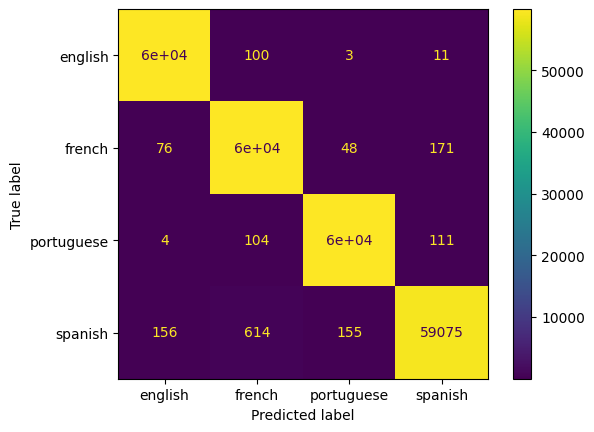

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions
)

In [29]:
print(model.classes_)

['english' 'french' 'portuguese' 'spanish']


In [31]:
joblib.dump(model, "../model_files/language_detector.pkl")

['../model_files/language_detector.pkl']

In [ ]:
#files.download("language_detector.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:
# ============================================================
# CARGA DE DATASETS SPAM/HAM MULTILINGÜES
# ============================================================

import pandas as pd

english_df = pd.read_csv(
    "../model_files/english_dataset.csv"
)

spanish_df = pd.read_csv(
    "../model_files/spanish_dataset.csv"
)

print("English:", english_df.shape)
print("Spanish:", spanish_df.shape)

English: (2893, 4)
Spanish: (1395, 4)


In [33]:
df = pd.concat(
    [english_df, spanish_df],
    ignore_index=True
)

print(df.shape)
df.head()

(4288, 4)


,subject,message,label,language
0,job posting - apple-iss research center,content - length : 3386 apple-iss research cen...,ham,english
1,NaN,"lang classification grimes , joseph e . and ba...",ham,english
2,query : letter frequencies for text identifica...,i am posting this inquiry for sergei atamas ( ...,ham,english
3,risk,a colleague and i are researching the differin...,ham,english
4,request book information,earlier this morning i was on the phone with a...,ham,english


In [34]:
print(df["label"].value_counts())

print("\nIdiomas:")
print(df["language"].value_counts())

label
ham     3076
spam    1212
Name: count, dtype: int64

Idiomas:
language
english    2893
spanish    1395
Name: count, dtype: int64


In [35]:
print(df.isnull().sum())

subject     65
message      0
label        0
language     0
dtype: int64


In [36]:
df["subject"] = df["subject"].fillna("")
df["message"] = df["message"].fillna("")

df["text"] = (
    df["subject"] + " " + df["message"]
)

In [37]:
import re

def clean_email_text(text):

    text = str(text).lower()

    text = re.sub(r"http\S+|www\S+", " URL ", text)

    text = re.sub(r"\S+@\S+", " EMAIL ", text)

    text = re.sub(r"\d+", " NUMBER ", text)

    text = re.sub(
        r"[^a-záéíóúñüàèìòùâêîôûãõç\s]",
        " ",
        text
    )

    text = re.sub(r"\s+", " ", text)

    return text.strip()

df["clean_text"] = df["text"].apply(
    clean_email_text
)

In [38]:
from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["clean_text"],
    df["label"],
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

In [39]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_spam = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1,2),
    max_features=50000,
    min_df=2
)

X_train = tfidf_spam.fit_transform(
    X_train_text
)

X_test = tfidf_spam.transform(
    X_test_text
)

print(X_train.shape)
print(X_test.shape)

(3430, 50000)
(858, 50000)


In [40]:
from sklearn.svm import LinearSVC

spam_model = LinearSVC()

spam_model.fit(
    X_train,
    y_train
)

print("Entrenamiento completado.")

Entrenamiento completado.


In [41]:
from sklearn.metrics import (
    classification_report,
    accuracy_score
)

predictions = spam_model.predict(
    X_test
)

print(
    classification_report(
        y_test,
        predictions
    )
)

print(
    "\nAccuracy:",
    accuracy_score(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

         ham       0.97      0.99      0.98       615
        spam       0.98      0.92      0.95       243

    accuracy                           0.97       858
   macro avg       0.97      0.96      0.96       858
weighted avg       0.97      0.97      0.97       858


Accuracy: 0.972027972027972


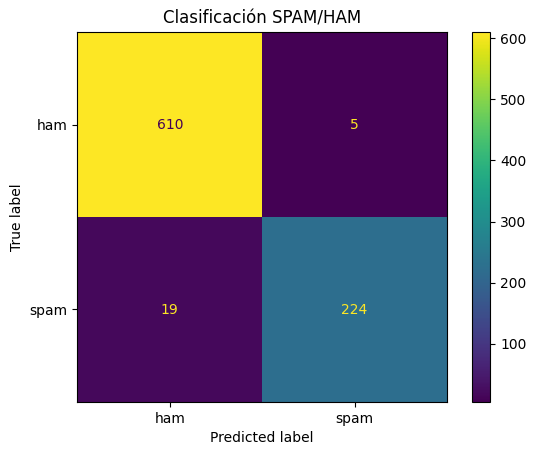

In [42]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    values_format="d"
)

plt.title(
    "Clasificación SPAM/HAM"
)

plt.show()

In [43]:
results_df = pd.DataFrame({
    "language": df.loc[X_test_text.index, "language"],
    "real": y_test,
    "predicted": predictions
})

results_df.head()

,language,real,predicted
4023,spanish,ham,ham
2049,english,spam,spam
1720,english,ham,ham
3943,spanish,ham,ham
52,english,ham,ham


In [44]:
for lang in results_df["language"].unique():

    print(f"\n===== {lang.upper()} =====")

    subset = results_df[
        results_df["language"] == lang
    ]

    from sklearn.metrics import classification_report

    print(
        classification_report(
            subset["real"],
            subset["predicted"]
        )
    )


===== SPANISH =====
              precision    recall  f1-score   support

         ham       0.90      0.97      0.94       145
        spam       0.97      0.90      0.93       146

    accuracy                           0.93       291
   macro avg       0.94      0.93      0.93       291
weighted avg       0.94      0.93      0.93       291


===== ENGLISH =====
              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       470
        spam       0.99      0.96      0.97        97

    accuracy                           0.99       567
   macro avg       0.99      0.98      0.98       567
weighted avg       0.99      0.99      0.99       567



In [45]:
%whos

Variable                   Type                          Data/Info
------------------------------------------------------------------
ConfusionMatrixDisplay     type                          <class 'sklearn.metrics._<...>.ConfusionMatrixDisplay'>
LinearSVC                  type                          <class 'sklearn.svm._classes.LinearSVC'>
LogisticRegression         type                          <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
MAX_SAMPLES_PER_LANGUAGE   int                           300000
Pipeline                   ABCMeta                       <class 'sklearn.pipeline.Pipeline'>
TfidfVectorizer            type                          <class 'sklearn.feature_e<...>on.text.TfidfVectorizer'>
X_test                     csr_matrix                    <Compressed Sparse Row sp<...>9827)	0.06793840614549967
X_test_text                Series                        4023    pésame la comunid<...>ength: 858, dtype: object
X_train                    csr_matrix         

In [46]:
import joblib
#from google.colab import files

joblib.dump(spam_model, "../model_files/spam_ham_model.pkl")
joblib.dump(tfidf_spam, "../model_files/tfidf_spam.pkl")
joblib.dump(model, "../model_files/language_detector_v1.pkl")

#files.download("spam_ham_model.pkl")
#files.download("tfidf_spam.pkl")
#files.download("language_detector_v1.pkl")

['../model_files/language_detector_v1.pkl']

In [48]:
import re
import joblib

spam_model = joblib.load("../model_files/spam_ham_model.pkl")
tfidf_spam = joblib.load("../model_files/tfidf_spam.pkl")
language_model = joblib.load("../model_files/language_detector_v1.pkl")

def clean_email_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " URL ", text)
    text = re.sub(r"\S+@\S+", " EMAIL ", text)
    text = re.sub(r"\d+", " NUMBER ", text)
    text = re.sub(r"[^a-záéíóúñüàèìòùâêîôûãõç\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def classify_email(subject, message):
    full_text = str(subject) + " " + str(message)
    clean_text = clean_email_text(full_text)

    language = language_model.predict([clean_text])[0]

    vector = tfidf_spam.transform([clean_text])

    prediction = spam_model.predict(vector)[0]

    return {
        "language": language,
        "classification": prediction
    }

In [49]:
result = classify_email(
    subject="URGENT: verify your account",
    message="Your account will be suspended. Click here now."
)

print(result)

{'language': 'english', 'classification': 'spam'}
